In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cvxopt as opt

import importlib

import itertools

import markowitz_optimization

import sys
import os
print(os.getcwd())

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import stock_filter
importlib.reload(markowitz_optimization)
importlib.reload(stock_filter)

c:\Users\User\Desktop\Github-local\GFWM\gfwm-app\data_science\quant


<module 'stock_filter' from 'c:\\Users\\User\\Desktop\\Github-local\\GFWM\\gfwm-app\\data_science\\stock_filter.py'>

In [ ]:
all_price_data = pd.read_csv("sp500_timeseries_13-24.csv")

entire_cov_matrix = pd.read_csv("sp500_adjusted_cov_matrix.csv")
entire_cov_matrix.set_index('ticker', inplace=True)

#read benchmarks:
#source: https://ycharts.com/indices/^SPX, https://www.msci.com/indexes/index/700719

benchmarks_df = pd.read_csv('benchmarks.csv')

# Convert to a dictionary to easily access by key
benchmarks = dict(zip(benchmarks_df['key'], benchmarks_df['value']))

# Assign constants to variables
SP500_annual_return = benchmarks.get("SP500_annual_return")
SP500_annual_volatility = benchmarks.get("SP500_annual_volatility")

SPESG_annual_return = benchmarks.get("SPESG_annual_return")
SPESG_annual_volatility = benchmarks.get("SPESG_annual_volatility")

In [3]:
unique_tickers = pd.Series(all_price_data.columns[1:].values)

n=100
tickers = unique_tickers.sample(frac=(n+5)/500, random_state=19).reset_index(drop=True)

# keep selected tickers
price_data = all_price_data[tickers]

# keep entries where both tickers are present
cov_matrix = entire_cov_matrix.loc[tickers, tickers].to_numpy()

mean_log_returns = price_data.mean(axis = 0)
#print(mean_log_returns * 252)

mu_bar = np.mean(mean_log_returns)
mu_sd = np.std(mean_log_returns)

# Convert to cvxopt matrices
cov = opt.matrix(cov_matrix)
mean_returns = opt.matrix(mean_log_returns)

# risk free rate based of historical average of 30d yield
annual_risk_free_rate = 0.0153

# daily target returns. scale to annual for graphing
# start at daily risk free rate
target_returns = np.linspace(start=pow(annual_risk_free_rate+1, 1/365.0) - 1, stop=mu_bar + mu_sd, num=50)

#TODO picking bounds: few different scenarios compared to equal weights

In [27]:
# generate portfolios
montecarlo_portfolios = markowitz_optimization.montecarlo_random_portfolios(mean_returns, 
                                                                            cov, 
                                                                            [0.0, 5.0/n], 
                                                                            iterations=1e5)

sp_optimal_portfolios, sp_best_fit = markowitz_optimization.calculate_optimal_portfolios(mean_returns, 
                                                                                   cov, 
                                                                                   target_returns, 
                                                                                   annual_risk_free_rate, 
                                                                                   bounds = [0.25/n, 4.0/n],
                                                                                   calculate_best_fit=True)

target_return                                                  0.00059
annual_return                                                 0.148804
annual_volatility                                             0.074972
weights              [0.0025085260102323554, 0.0025181270728730967,...
diversification                                               0.868169
Name: 36, dtype: object
99.89999999999999


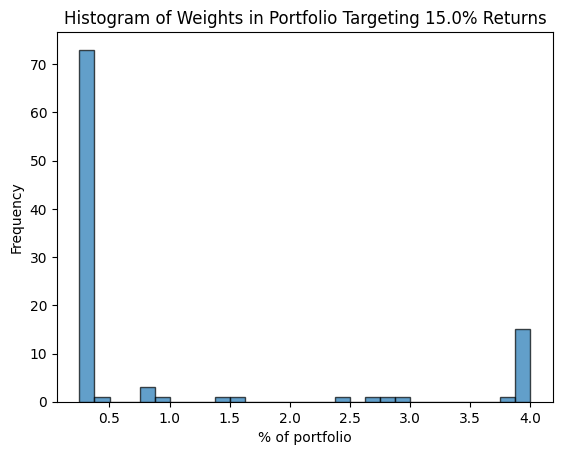

In [21]:
#find the portfolio nearest a given target return

sp_optimal_portfolios_sorted = sp_optimal_portfolios.sort_values(by='annual_return', ascending= True)
target_return = 0.15
closest_portfolio = sp_optimal_portfolios_sorted.loc[(sp_optimal_portfolios_sorted['annual_return'] - target_return).abs().idxmin()]
closest_portfolio_weights = closest_portfolio['weights'] * 100

print(closest_portfolio)

print(sum(closest_portfolio_weights))

plt.hist(closest_portfolio_weights, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('% of portfolio')
plt.ylabel('Frequency')
plt.title(f'Histogram of Weights in Portfolio Targeting {target_return * 100}% Returns')
plt.show()

In [38]:
def tangent_portfolio(returns, volatilities):
    
    # Calculate quadratic best fit
    # annual_return as independent variable, annual_volatility as dependent variable
    best_fit = np.polynomial.Polynomial.fit(returns, 
                                            volatilities, 
                                            2, domain=[0.0, 0.5])


    #calculate tangent line to best fit curve, passing through (0, annual_rfr)
    # vol = ar^2 + br + c
    # derivative: 2ar + b

    # point slope form of line also passing through (vol_t, ret_t)
    # vol - vol_t = slope * (ret - ret_t)

    # at the tangency point (vol_t, ret_t), slopes are equal:
    # vol_t / (ret_t - rfr) = 2a * ret_t + b
    # solve for ret_t to find the tangency point (ret_t, vol_t)

    # best_fit(ret_t) / (ret_t - rfr) = 2a * ret_t + b
    # ar^2 + br + c = (r-rfr)(2ar+b)
    #               = 2a r^2 + (b-2arfr) * r - rfr*b
    # 0 = ar^2 - 2arfr * r - c - rfr*b

    [c, b, a] = best_fit.convert().coef
    tangency_poly = np.polynomial.Polynomial([-c - b * annual_risk_free_rate, 
                                            -2*a* annual_risk_free_rate,
                                            a])
    #find root in the acceptable range
    ret_t = [root for root in tangency_poly.roots() if 0 <= root <= 0.5][0]
    vol_t = best_fit(ret_t)
    
    return (ret_t, vol_t)

def tangent_line(r, ret_t, vol_t):
    slope = vol_t / (ret_t - annual_risk_free_rate)
    return vol_t + (slope * (r-ret_t))

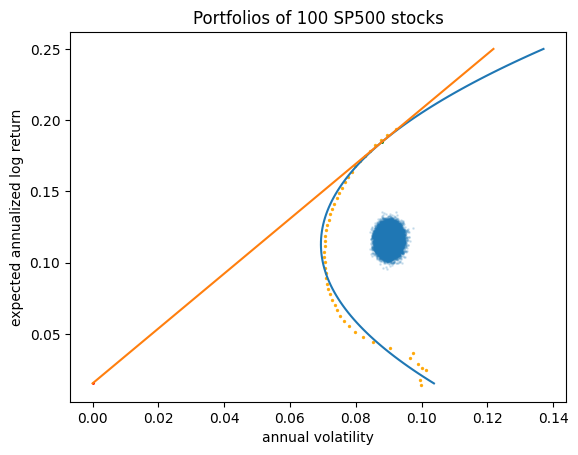

In [40]:
fig1 = plt.figure()

plt.scatter(montecarlo_portfolios['annual_volatility'],
            montecarlo_portfolios['annual_return'], s=1, alpha=0.15)

plt.scatter(sp_optimal_portfolios['annual_volatility'],
            sp_optimal_portfolios['annual_return'], s=2, c='orange', alpha=0.9)

plt.scatter(0, annual_risk_free_rate, s= 1, color='red')

x = np.linspace(start=annual_risk_free_rate, stop = 0.25, num = 100)

plt.plot([sp_best_fit(xi) for xi in x], x)
(sp_tangent_return, sp_tangent_volatility) = tangent_portfolio(sp_optimal_portfolios['annual_return'],
                                                                  sp_optimal_portfolios['annual_volatility'])

plt.scatter(sp_tangent_volatility, sp_tangent_return, s= 1, color='green')

plt.ylabel('expected annualized log return')
plt.xlabel('annual volatility')

plt.plot([tangent_line(xi, sp_tangent_return, sp_tangent_volatility) for xi in x], x)

plt.title(f"Portfolios of {n} SP500 stocks")
plt.show()

In [36]:
factors = ['environment', 'human_rights','workforce','product_responsibility',
           'shareholders','community','governance']

# 7 factors choose 3 = 35
num_combinations = 35

# Use a colormap to generate a set of distinct colors. 'tab20' is another option
colormap = plt.colormaps['tab20'].resampled(num_combinations)
colors = [colormap(i) for i in range(num_combinations)]

user_preferences_dicts = []
markowitz_results = []

for combination in itertools.combinations(factors, 3):
    
    user_preferences_dict = {}
    for factor in factors:
        if factor in combination:
            user_preferences_dict[factor] = 10
        else:
            user_preferences_dict[factor] = 5
    
    user_preferences_dicts.append(user_preferences_dict)


for combination, tickers in stock_filter.filter_stocks_mass(user_preferences_dicts):
    
    # keep tickers for which we have price data
    tickers = list(set(tickers) & set(unique_tickers))
    
    # select relevant price and covariance data
    price_data = all_price_data[tickers]
    cov = opt.matrix(entire_cov_matrix.loc[tickers, tickers].to_numpy())
    
    mean_returns = opt.matrix(price_data.mean(axis=0))

    optimal_portfolios = markowitz_optimization.calculate_optimal_portfolios(mean_returns,
                                                                             cov,
                                                                             target_returns,
                                                                             annual_risk_free_rate,
                                                                             bounds=[0.25/n, 4.0/n])
    markowitz_results.append((combination, (optimal_portfolios['annual_volatility'],
                                           optimal_portfolios['annual_return'])))

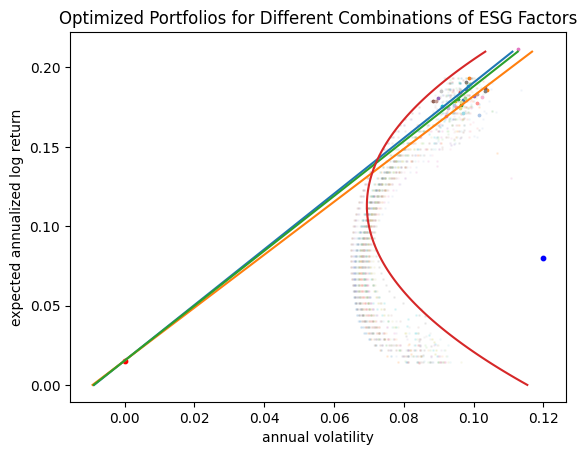

In [ ]:
fig2 = plt.figure()

for idx, (combination, points) in enumerate(markowitz_results):
    
    #volatilities stored in points[0], returns stored in points[1]
    (tangent_return, tangent_volatility) = tangent_portfolio(points[1], points[0])
    
    plt.scatter(tangent_volatility, tangent_return, s=3, color=colors[idx], alpha=1, label=combination)
    plt.scatter(points[0], points[1], s=1, color = colors[idx], alpha = 0.1)
    
    if(idx % 14 ==0):    
        plt.plot([tangent_line(xi, tangent_return, tangent_volatility) for xi in x], x)


x = np.linspace(start=0.0, stop = 0.21, num = 100)

plt.plot([sp_best_fit(xi) for xi in x], x)

plt.scatter(0, annual_risk_free_rate, s=10, color='red')
plt.scatter(SP500_annual_volatility, SP500_annual_return, s=10, color='blue')
plt.scatter(SPESG_annual_volatility, SPESG_annual_return, s=10, color='green')

plt.xlabel('annual volatility')
plt.ylabel('expected annualized log return')

plt.title(f"Optimized Portfolios for Different Combinations of ESG Factors")
#plt.legend()
plt.show()

#sp esg dot: SPESG

#two phases: stability of different esg fctors

#next phase: tell story for just one combination of factors (ex pink dot)

#point out distance tangency points 
# to efficient frontier

#compare bar graphs of sp500 weights vs esg weights
#show top 10 tickers by esg weight vs which are top 10 in voo

#show ideal portfolio using only e factors vs only s factors vs only g

In [ ]:
# given that optimal_portfolios is already sorted by return, find the row closest to ret_t
ideal_portfolio = optimal_portfolios.loc[(optimal_portfolios['annual_return'] - ret_t).abs().idxmin()][['annual_return', 'annual_volatility', 'weights']]

ideal_portfolio_df = pd.DataFrame({
    'annual_return': [ideal_portfolio['annual_return']] + [None] * (n - 1),
    'annual_volatility': [ideal_portfolio['annual_volatility']] + [None] * (n - 1),
    'weights': ideal_portfolio['weights']
})

#print(ideal_portfolio_df)

ideal_portfolio_df.to_csv("ideal_portfolio.csv", index=False)

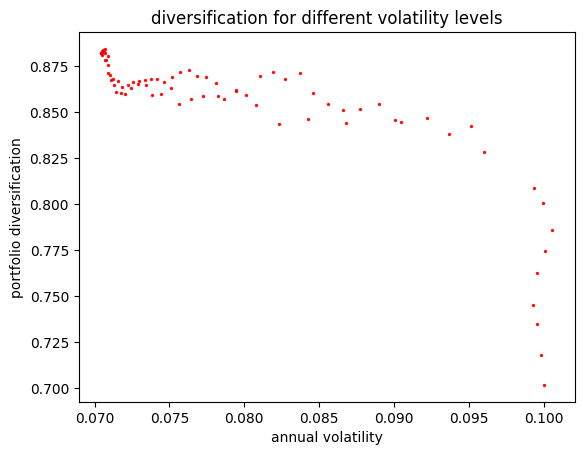

In [ ]:
plt.scatter(optimal_portfolios['annual_volatility'],
            optimal_portfolios['diversification'], s=2, c='red', alpha=0.9)
plt.xlabel('annual volatility')
plt.ylabel('portfolio diversification')
plt.title('diversification for different volatility levels')
plt.show()